In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 6
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2
%config InlineBackend.figure_format='retina'

import sys
from pathlib import Path
sys.path.append('../')
from utils import *  # key functions for this project

THRESHOLD = 50


# Example trajectory, CTCF

In [2]:
rep = 14
loop_num = 0
dt = 30
sample_every = 1 * dt

traj = load_trajectory(loop_num, rep, noise=0)

FileNotFoundError: /mnt/md0/jjusuf/looping_review/processed_data/loop_0_14_step_1_noise_0um.txt not found.

In [3]:
median = np.median(traj)

x_start = 3000
x_end = 14500
x_range = np.arange(x_start, x_end, sample_every)
x_range_min = np.arange(len(x_range)) * dt / 60

fig, ax = plt.subplots(figsize=(4,1.5))

ax.plot(x_range_min, traj.iloc[x_range], color='#cc3311');

ax.add_patch(plt.Rectangle((0, 0), x_range_min[-1]-x_range_min[0], 50, ec="none", fc="#dddddd", zorder=-1))
ax.add_patch(plt.Rectangle((0, median), x_range_min[-1]-x_range_min[0], 50, ec="none", fc="#f7e5e1", zorder=-1))
ax.set_xlim(x_range_min[0], x_range_min[-1]);
ax.set_ylim(0, 950);

ax.set_xlabel('time [min.]')
ax.set_ylabel('3D distance [nm]');

plt.savefig('../figure_exports/fig3a.svg')


NameError: name 'traj' is not defined

# CTCF plots

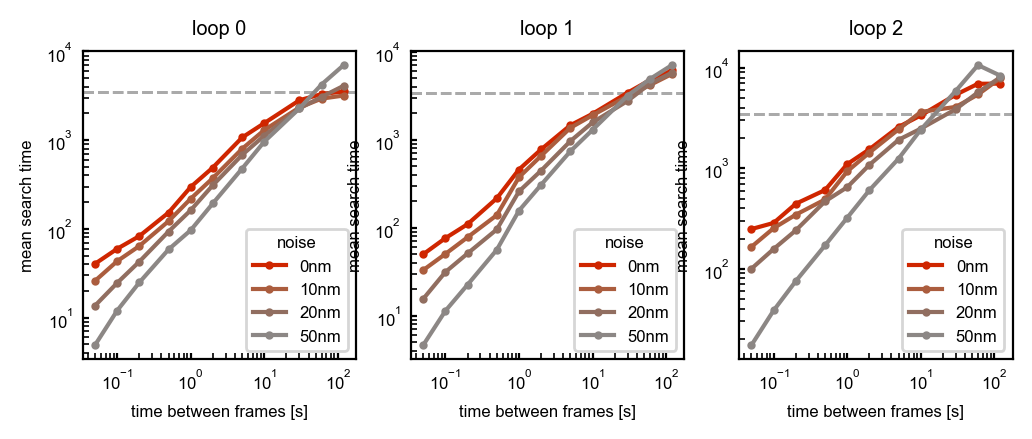

In [18]:
dt_arr = np.array([0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 30, 60, 120])

search_times_CTCF_list = [pd.read_csv(f'../data/search_times_CTCF_deltaT_{dt_arr[0]}s.csv')]
for dt in dt_arr[1:]:
    temp_df = pd.read_csv(f'../data/search_times_CTCF_deltaT_{dt}s.csv')
    temp_df['dt'] = [dt] * len(temp_df)
    search_times_CTCF_list.append(temp_df)
search_times_CTCF = pd.concat(search_times_CTCF_list)

search_times_CTCF_actual = pd.read_csv('../data/search_times_CTCF_actual.csv')

CTCF_loops = [0, 1, 2]

colors = {0: '#cf2600',
          10: '#ab5d3e',
          20: '#916e60',
          50: '#8c8785'}

fig, axs = plt.subplots(1, 3, figsize=(6, 2))
for ax_index, loop_num in enumerate(CTCF_loops):
    for noise in [0, 10, 20, 50]:
        x = []
        y = []
        for dt in dt_arr:
            x.append(dt)
            y.append(np.mean(search_times_CTCF.loc[(search_times_CTCF['loop']==loop_num) & 
                                (search_times_CTCF['noise']==noise) &
                                (search_times_CTCF['dt']==dt), 'time']))
        axs[ax_index].plot(x, y, marker='o', ms=2, label=f'{noise}nm', color=colors[noise])
        axs[ax_index].axhline(np.mean(search_times_CTCF_actual.loc[(search_times_CTCF_actual['loop']==loop_num),'time']), color='#aaaaaa', linestyle='--', linewidth=1, zorder=-1)
    handles, labels = axs[ax_index].get_legend_handles_labels()
    axs[ax_index].set_xscale('log')
    axs[ax_index].set_yscale('log')
    axs[ax_index].set_xlabel('time between frames [s]')
    axs[ax_index].set_ylabel('mean search time');
    axs[ax_index].legend(handles=handles, title='noise');
    axs[ax_index].set_title(f'loop {loop_num}')

plt.savefig('../figure_exports/Fig3_CTCF_search_times_all.svg')

# Example trajectory, EP

In [202]:
rep = 14
loop_num = 3
dt = 0.1
sample_every = 50 * dt

traj = load_trajectory(loop_num, rep, noise=0)

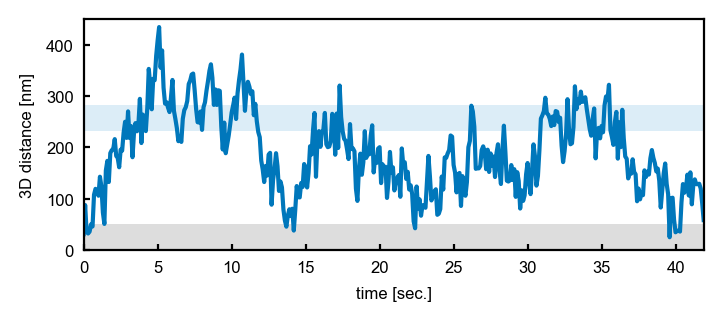

In [203]:
median = np.median(traj)

x_start = 1100
x_end = 3200
x_range = np.arange(x_start, x_end, sample_every)
x_range_min = np.arange(len(x_range)) * dt

fig, ax = plt.subplots(figsize=(4,1.5))

ax.plot(x_range_min, traj.iloc[x_range], color='#0077bb');

ax.add_patch(plt.Rectangle((0, 0), x_range_min[-1]-x_range_min[0], 50, ec="none", fc="#dddddd", zorder=-1))
ax.add_patch(plt.Rectangle((0, median), x_range_min[-1]-x_range_min[0], 50, ec="none", fc="#dcedf7", zorder=-1))
ax.set_xlim(x_range_min[0], x_range_min[-1]);
ax.set_ylim(0, 450);

ax.set_xlabel('time [sec.]')
ax.set_ylabel('3D distance [nm]')

plt.savefig('../figure_exports/fig3b.svg')


# EP plots

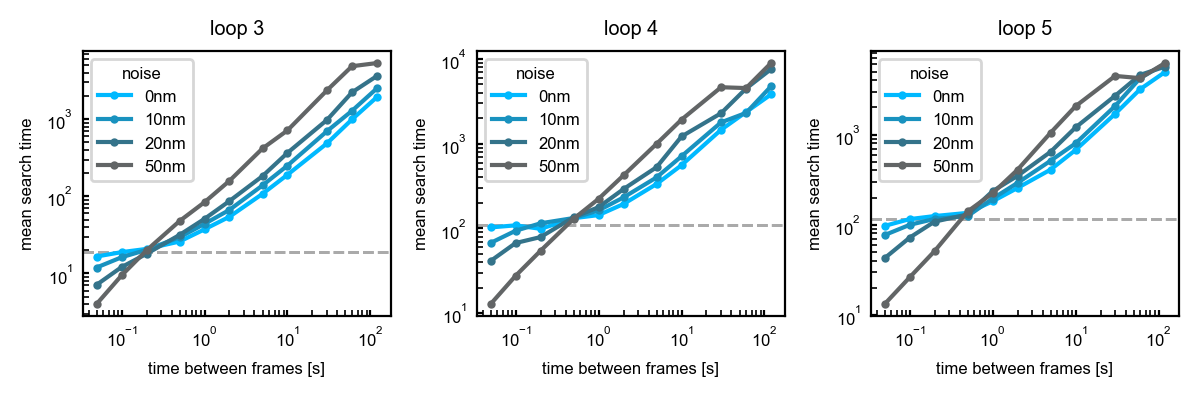

In [ ]:
dt_arr = np.array([0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 30, 60, 120])

search_times_EP_list = [pd.read_csv(f'../data/search_times_EP_deltaT_{dt_arr[0]}s.csv')]
for dt in dt_arr[1:]:
    temp_df = pd.read_csv(f'../data/search_times_EP_deltaT_{dt}s.csv')
    temp_df['dt'] = [dt] * len(temp_df)
    search_times_EP_list.append(temp_df)
search_times_EP = pd.concat(search_times_EP_list)

EP_loops = [3, 4, 5]

colors = {0: '#00b9ff',
          10: '#1992bf',
          20: '#34738a',
          50: '#626566'}

fig, axs = plt.subplots(1, 3, figsize=(6, 2))
for ax_index, loop_num in enumerate(EP_loops):
    for noise in [0, 10, 20, 50]:
        x = []
        y = []
        for dt in dt_arr:
            x.append(dt)
            y.append(np.mean(search_times_EP.loc[(search_times_EP['loop']==loop_num) & 
                                (search_times_EP['noise']==noise) &
                                (search_times_EP['dt']==dt), 'time']))
        axs[ax_index].plot(x, y, marker='o', ms=2, label=f'{noise}nm', color=colors[noise])
        axs[ax_index].axhline(np.mean(search_times_EP.loc[((search_times_EP['loop']==loop_num) &
                                                (search_times_EP['noise']==0) &
                                                (search_times_EP['dt']==0.1)),'time']), 0, 1, color='#aaaaaa', linestyle='--', linewidth=1, zorder=-1)
    handles, labels = axs[ax_index].get_legend_handles_labels()
    axs[ax_index].set_xscale('log')
    axs[ax_index].set_yscale('log')
    axs[ax_index].set_xlabel('time between frames [s]')
    axs[ax_index].set_ylabel('mean search time');
    axs[ax_index].legend(handles=handles, title='noise');
    axs[ax_index].set_title(f'loop {loop_num}')

plt.tight_layout()
plt.savefig('../figure_exports/Fig3_CTCF_search_times_all.svg')
